In [5]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *

# VERIFICA SE O PRESENTE JUSTIFICA O FUTURO, NAO SE UTILIZA LAG

In [6]:
# df_btc_price = pd.read_csv(rf"/home/baia/z/git/data-science-analytics/TCC/data/dados_btc/raw/price_btc.csv")
df_btc_price = pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_btc/raw/price_btc.csv")
df_btc_price['Data_UTC'] = pd.to_datetime(df_btc_price['time'], unit='s', utc=True,).dt.strftime("%Y-%m-%d")

df_sp500 = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/2014_SP500_PRICE.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)

df_sp500_log_Ret =(
    df_periodo
        .merge(df_sp500, how='left', on='Data_UTC')
        # Preço se mantém ao FDS
        .assign(close_price = lambda df: df['close_price'].fillna(method='ffill'))
        .assign(SPX_Log_Ret = lambda df: np.log(df['close_price']) - np.log(df['close_price'].shift(1)))


        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','close_price','SPX_Log_Ret']]

)
df_sp500_log_Ret

df_vix = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/201501_VIX.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)
df_vix

df_vix_log_ret =(
    df_periodo
        .merge(df_vix, how='left', on='Data_UTC')
        .assign(close_price = lambda df: df['close_price'].ffill())
        .assign(VIX_Log_Ret = lambda df: np.log(df['close_price']) - np.log(df['close_price'].shift(1)))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','close_price','VIX_Log_Ret']]

)
df_vix_log_ret

df_us10y = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/201501_US10Y.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)
df_us10y

df_us10y_diff =(
    df_periodo
        .merge(df_us10y, how='left', on='Data_UTC')
        .assign(close_price = lambda df: df['close_price'].ffill())
        .assign(US10Y_Diff = lambda df: df['close_price'].diff())

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','close_price','US10Y_Diff']]

)
df_us10y_diff

/var/folders/h1/_3z4z04x4j17zlfj224w53hr0000gn/T/ipykernel_14777/4063713309.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .assign(close_price = lambda df: df['close_price'].fillna(method='ffill'))


,Data_UTC,close_price,US10Y_Diff
4,2017-01-04,2.4413,-0.0059
5,2017-01-05,2.3479,-0.0934
6,2017-01-06,2.4221,0.0742
7,2017-01-07,2.4221,0.0000
8,2017-01-08,2.4221,0.0000
...,...,...,...
3131,2025-07-28,4.3240,-0.0900
3132,2025-07-29,4.3720,0.0480
3133,2025-07-30,4.3820,0.0100
3134,2025-07-31,4.2160,-0.1660


In [7]:
# Base dataframe
df_final_feature = df_periodo.copy()

# Left join com df_btc_price
df_final_feature = df_final_feature.merge(
    df_btc_price[['Data_UTC', 'close']],
    on='Data_UTC',
    how='left'
).rename(columns={
    'close': 'btc_close'
})

# Left join com df_sp500_log_Ret
df_final_feature = df_final_feature.merge(
    df_sp500_log_Ret,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'sp500_close'})

# Left join com df_vix_log_ret
df_final_feature = df_final_feature.merge(
    df_vix_log_ret,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'vix_close'})

# Left join com df_us10y_diff
df_final_feature = df_final_feature.merge(
    df_us10y_diff,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'us10y_close'})

df_final_feature = df_final_feature.ffill().query("Data_UTC >= '2017-01-04'").reset_index(drop=True)

df_final_feature = df_final_feature.assign(Data_UTC=pd.to_datetime(df_final_feature['Data_UTC']))

df_final_feature = df_final_feature.assign( btc_Log_Ret = lambda df: np.log(df['btc_close']) - np.log(df['btc_close'].shift(1)))
df_final_feature

,Data_UTC,is_weekend,btc_close,sp500_close,SPX_Log_Ret,vix_close,VIX_Log_Ret,us10y_close,US10Y_Diff,btc_Log_Ret
0,2017-01-04,0,1130.39975,2270.75,0.005706,11.85,-0.081016,2.4413,-0.0059,NaN
1,2017-01-05,0,1005.64250,2269.00,-0.000771,11.67,-0.015306,2.3479,-0.0934,-0.116945
2,2017-01-06,0,894.70325,2276.98,0.003511,11.32,-0.030450,2.4221,0.0742,-0.116890
3,2017-01-07,1,907.65000,2276.98,0.000000,11.32,0.000000,2.4221,0.0000,0.014367
4,2017-01-08,1,915.99975,2276.98,0.000000,11.32,0.000000,2.4221,0.0000,0.009157
...,...,...,...,...,...,...,...,...,...,...
3127,2025-07-28,0,118085.05000,6389.76,0.000174,15.04,0.008011,4.3240,-0.0900,-0.011507
3128,2025-07-29,0,117940.69000,6370.87,-0.002961,15.97,0.059999,4.3720,0.0480,-0.001223
3129,2025-07-30,0,117815.05000,6362.89,-0.001253,15.47,-0.031809,4.3820,0.0100,-0.001066
3130,2025-07-31,0,115760.52000,6339.38,-0.003702,16.71,0.077105,4.2160,-0.1660,-0.017592


In [8]:
display(df_features.columns)
display(df_target_price.columns)

Index(['Data_UTC', 'is_weekend', 'rvi_close', 'rvi_diff',
       'total_funding_rate_btc', 'funding_rate_diff_btc',
       'supply_held_by_miners_btc', 'miner_net_pos_change',
       'supply_on_exchanges_perc_btc', 'exchange_supply_diff_btc', 'spx_price',
       'btc_log_ret', 'btc_spx_corr_30d', 'cb_premium_usd',
       'cb_premium_diff_btc', 'mvrv_close', 'mvrv_diff_btc',
       'whale_100k_log_ret', 'whale_transaction_count_100k_btc',
       'whale_1m_log_ret', 'whale_transaction_count_1M_btc', 'spx_close',
       'spx_log_ret', 'gold_close', 'gold_log_ret', 'us10y_close',
       'us10y_diff', 'vix_close', 'vix_log_ret', 'total3_close',
       'total3_log_ret', 'ssr', 'ssr_diff', 'flippening_close',
       'flippening_close_diff', 'social_vol_log_spread', 'social_momentum',
       'usdt_dominance', 'usdt_log_ret', 'usdc_dominance', 'usdc_log_ret',
       'btc_price', 'nasdaq_close', 'nasdaq_log_ret', 'dxy_close',
       'dxy_log_ret'],
      dtype='object')

Index(['Data_UTC', 'btc_price'], dtype='object')

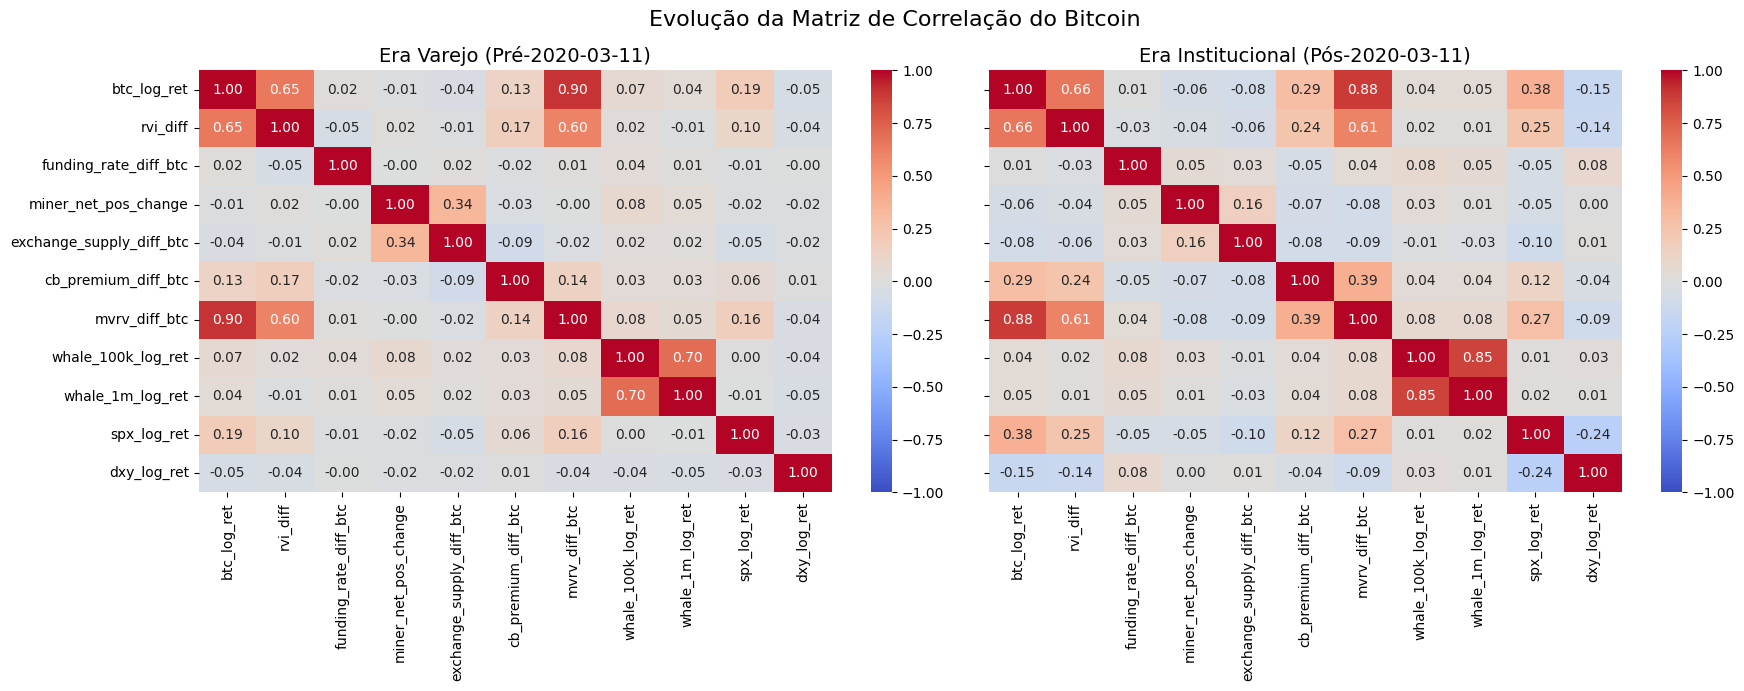

In [9]:
# ==============================================================================
# 3. MATRIZES DE CORRELAÇÃO COMPARATIVAS (Para a Seção 3.3)
# ==============================================================================

# Selecionar variáveis TRANSFORMADAS (Stationary)
# Selecionar variáveis TRANSFORMADAS (Stationary)
cols_corr = ['btc_log_ret', 'rvi_diff','funding_rate_diff_btc', 'miner_net_pos_change','exchange_supply_diff_btc',
             'cb_premium_diff_btc','mvrv_diff_btc','whale_100k_log_ret','whale_1m_log_ret','spx_log_ret','dxy_log_ret',
             'nasdaq_log_ret','gold_log_ret','us10y_diff','vix_log_ret','total3_log_ret','ssr_diff','flippening_close_diff','social_vol_log_spread',
             'social_momentum','usdt_log_ret','usdc_log_ret']

# Dividir a lista em duas metades
mid_point = len(cols_corr) // 2
cols_corr1 = cols_corr[:mid_point]
cols_corr2 = cols_corr[mid_point:]

cols_corr = cols_corr1

# Dividir os dados
df_varejo = df_features.loc[:DATA_DIVISAO_ERA][cols_corr]
df_institucional = df_features.loc[DATA_DIVISAO_ERA:][cols_corr]
# Calcular Matrizes de Correlação (Pearson)
corr_varejo = df_varejo.corr()
corr_institucional = df_institucional.corr()

# Plotar Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Heatmap 1: Era Varejo
sns.heatmap(corr_varejo, ax=axes[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[0].set_title(f'Era Varejo (Pré-{DATA_DIVISAO_ERA})', fontsize=14)

# Heatmap 2: Era Institucional
sns.heatmap(corr_institucional, ax=axes[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[1].set_title(f'Era Institucional (Pós-{DATA_DIVISAO_ERA})', fontsize=14)
plt.suptitle('Evolução da Matriz de Correlação do Bitcoin', fontsize=16)
plt.tight_layout()
plt.show()

# O que procurar aqui: Veja se o quadrado entre btc_Log_Ret e SPX_Log_Ret ficou "mais vermelho" no segundo gráfico. 
# Se sim, sua tese está provada visualmente.

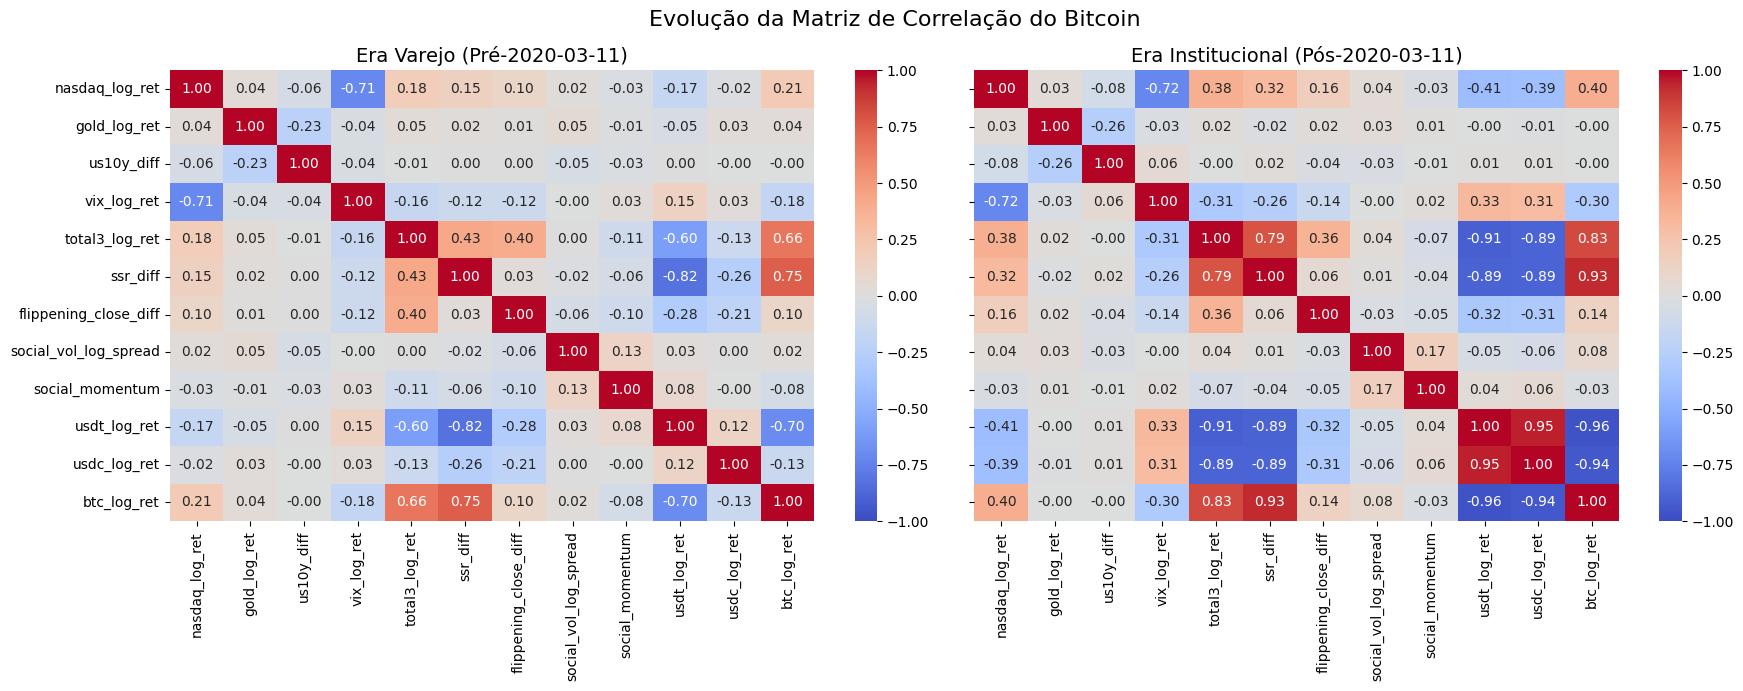

In [10]:
# ==============================================================================
# 3. MATRIZES DE CORRELAÇÃO COMPARATIVAS (Para a Seção 3.3)
# ==============================================================================

# Selecionar variáveis TRANSFORMADAS (Stationary)
# Selecionar variáveis TRANSFORMADAS (Stationary)
cols_corr = ['btc_log_ret', 'rvi_diff','funding_rate_diff_btc', 'miner_net_pos_change','exchange_supply_diff_btc',
             'cb_premium_diff_btc','mvrv_diff_btc','whale_100k_log_ret','whale_1m_log_ret','spx_log_ret','dxy_log_ret',
             'nasdaq_log_ret','gold_log_ret','us10y_diff','vix_log_ret','total3_log_ret','ssr_diff','flippening_close_diff','social_vol_log_spread',
             'social_momentum','usdt_log_ret','usdc_log_ret','btc_log_ret']

# Dividir a lista em duas metades
mid_point = len(cols_corr) // 2
cols_corr1 = cols_corr[:mid_point]
cols_corr2 = cols_corr[mid_point:]

cols_corr = cols_corr2

# Dividir os dados
df_varejo = df_features.loc[:DATA_DIVISAO_ERA][cols_corr]
df_institucional = df_features.loc[DATA_DIVISAO_ERA:][cols_corr]
# Calcular Matrizes de Correlação (Pearson)
corr_varejo = df_varejo.corr()
corr_institucional = df_institucional.corr()

# Plotar Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Heatmap 1: Era Varejo
sns.heatmap(corr_varejo, ax=axes[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[0].set_title(f'Era Varejo (Pré-{DATA_DIVISAO_ERA})', fontsize=14)

# Heatmap 2: Era Institucional
sns.heatmap(corr_institucional, ax=axes[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[1].set_title(f'Era Institucional (Pós-{DATA_DIVISAO_ERA})', fontsize=14)
plt.suptitle('Evolução da Matriz de Correlação do Bitcoin', fontsize=16)
plt.tight_layout()
plt.show()

# O que procurar aqui: Veja se o quadrado entre btc_Log_Ret e SPX_Log_Ret ficou "mais vermelho" no segundo gráfico. 
# Se sim, sua tese está provada visualmente.

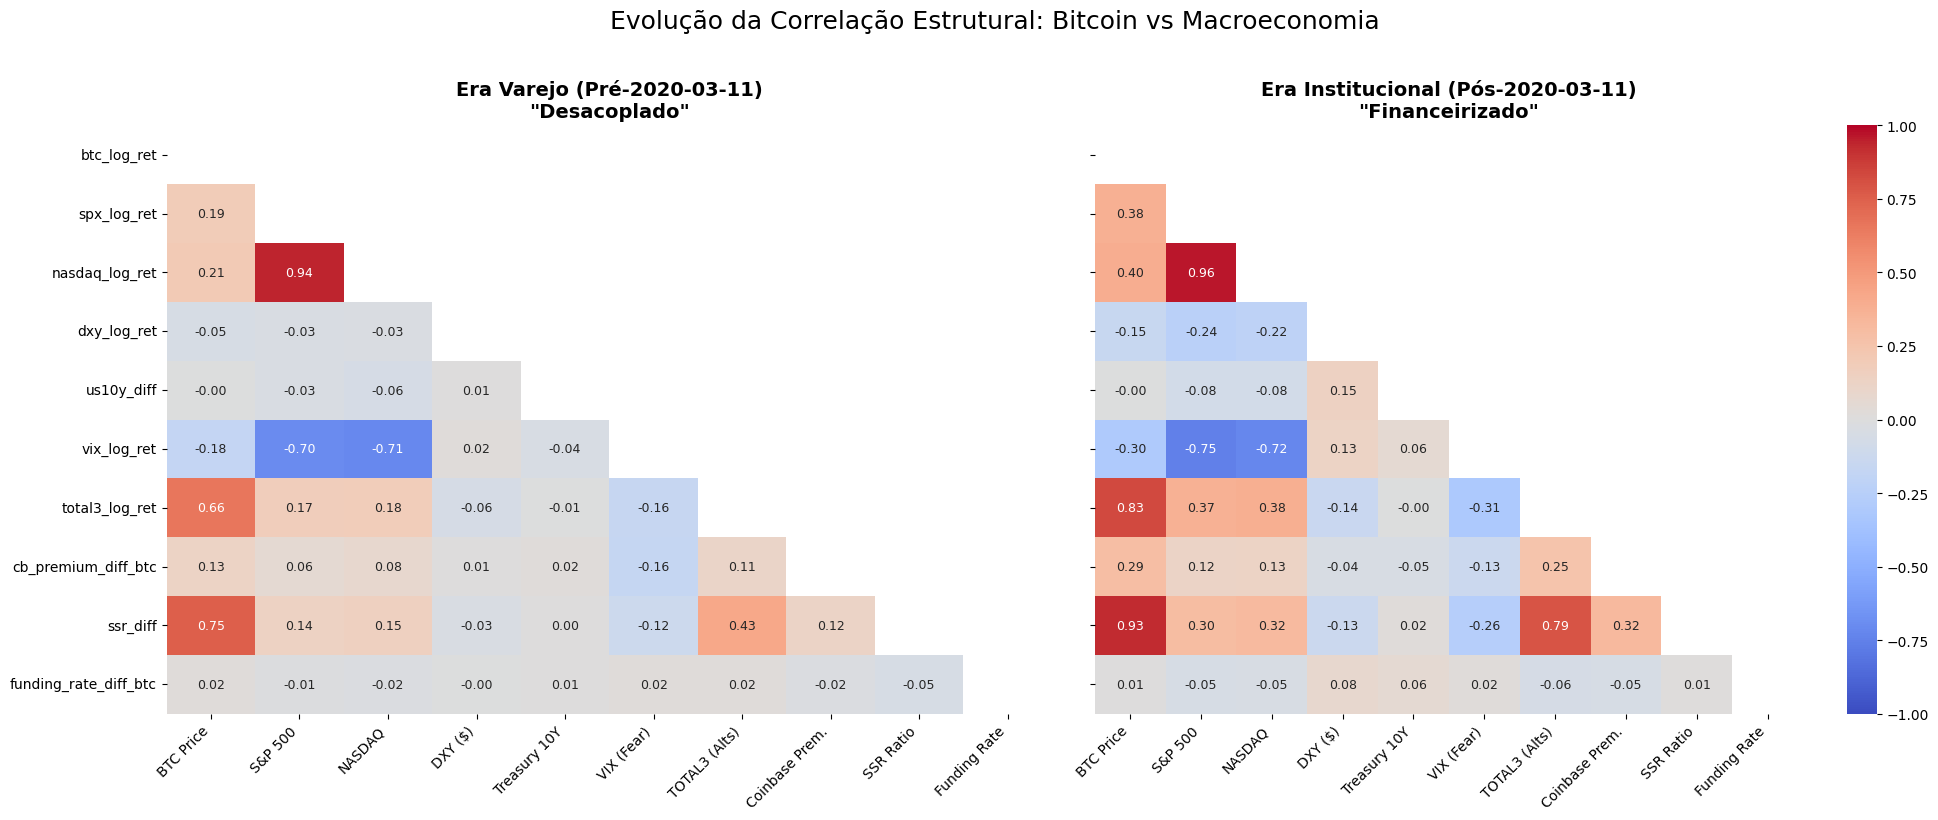

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# SELEÇÃO DO "DREAM TEAM" DE VARIÁVEIS
# ==============================================================================
# Selecionamos apenas as variáveis que validam a tese de Financeirização
# Target: btc_log_ret
cols_dream_team = [
    'btc_log_ret',              # O ALVO (Preço)
    'spx_log_ret',              # S&P 500 (Risco Global)
    'nasdaq_log_ret',              # NASDAQ (Setor Tech)
    'dxy_log_ret',            # Dólar (Liquidez Fiat)
    'us10y_diff',               # Juros (Custo de Oportunidade)
    'vix_log_ret',              # VIX (Medo)
    'total3_log_ret',           # Altcoins (Apetite de Risco Crypto)
    'cb_premium_diff_btc',      # Institucional (Coinbase)
    'ssr_diff',                 # Stablecoin Supply (Pólvora Seca)
    'funding_rate_diff_btc'     # Alavancagem Especulativa
]

# Títulos amigáveis para o Gráfico (Opcional, mas fica lindo no TCC)
labels_amigaveis = [
    'BTC Price', 'S&P 500', 'NASDAQ', 'DXY ($)', 'Treasury 10Y', 
    'VIX (Fear)', 'TOTAL3 (Alts)', 'Coinbase Prem.', 'SSR Ratio', 'Funding Rate'
]

# ==============================================================================
# PREPARAÇÃO DOS DADOS
# ==============================================================================

df_clean = df_features[cols_dream_team].copy()

# Dividir os dados temporalmente
df_varejo = df_clean.loc[:DATA_DIVISAO_ERA]
df_institucional = df_clean.loc[DATA_DIVISAO_ERA:]

# Calcular Matrizes de Correlação (Pearson)
corr_varejo = df_varejo.corr()
corr_institucional = df_institucional.corr()

# ==============================================================================
# PLOTAGEM COM MÁSCARA (Visual Limpo)
# ==============================================================================

# Criar máscara para esconder o triângulo superior (evita informação duplicada)
mask_varejo = np.triu(np.ones_like(corr_varejo, dtype=bool))
mask_inst = np.triu(np.ones_like(corr_institucional, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Heatmap 1: Era Varejo
sns.heatmap(corr_varejo, ax=axes[0], mask=mask_varejo, annot=True, 
            cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", 
            cbar=False, annot_kws={"size": 9})
axes[0].set_title(f'Era Varejo (Pré-{DATA_DIVISAO_ERA})\n"Desacoplado"', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(labels_amigaveis, rotation=45, ha='right')
axes[0].set_yticklabels(labels_amigaveis, rotation=0)

# Heatmap 2: Era Institucional
sns.heatmap(corr_institucional, ax=axes[1], mask=mask_inst, annot=True, 
            cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", 
            cbar=True, annot_kws={"size": 9})
axes[1].set_title(f'Era Institucional (Pós-{DATA_DIVISAO_ERA})\n"Financeirizado"', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(labels_amigaveis, rotation=45, ha='right')

plt.suptitle('Evolução da Correlação Estrutural: Bitcoin vs Macroeconomia', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()